<a href="https://colab.research.google.com/github/kurhadenarayan44-a11y/AI-Particle-Collision-Detection/blob/main/project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Netflix Customer Churn Prediction: Exploratory Data Analysis (EDA)

## 1. Setup and Data Loading

First, we'll import the necessary libraries and load the dataset. Since the data is provided in a zip file, we'll first unzip it and then load the CSV file into a pandas DataFrame.

In [8]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set default plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# Unzip the dataset file
print("Unzipping the archive...")
!unzip -o '/content/archive (11).zip'

# List files in the current directory to find the CSV
print("\nFiles in the current directory after unzipping:")
!ls

# Assuming the CSV file is named 'netflix_customer_churn.csv' or similar.
# If the actual CSV name is different, please update 'csv_file_name'.
csv_file_name = None
for file in os.listdir('.'):
    if file.endswith('.csv') and 'churn' in file.lower():
        csv_file_name = file
        break

if csv_file_name:
    print(f"\nFound CSV file: {csv_file_name}. Loading data...")
    df = pd.read_csv(csv_file_name)
    print("Data loaded successfully!")
else:
    print("\nCould not find a CSV file related to 'churn' in the unzipped contents.")
    print("Please check the file name and update 'csv_file_name' in the code.")
    # Create an empty DataFrame to avoid errors in subsequent cells if no CSV is found
    df = pd.DataFrame()

# Display the first 5 rows of the dataset
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Display the last 5 rows of the dataset
print("\nLast 5 rows of the dataset:")
display(df.tail())

Unzipping the archive...
Archive:  /content/archive (11).zip
  inflating: netflix_customer_churn.csv  

Files in the current directory after unzipping:
'archive (11).zip'	      netflix_customer_churn.numbers
 netflix_customer_churn.csv   sample_data

Found CSV file: netflix_customer_churn.csv. Loading data...
Data loaded successfully!

First 5 rows of the dataset:


,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action



Last 5 rows of the dataset:


,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
4995,44f3ba44-b95d-4e50-a786-bac4d06f4a43,19,Female,Basic,49.17,11,Europe,Desktop,8.99,0,Credit Card,4,4.10,Drama
4996,18779bcb-ba2b-41da-b751-e70b812061ec,67,Female,Basic,9.24,2,North America,Desktop,8.99,0,PayPal,3,3.08,Documentary
4997,3f32e8c5-615b-4a3b-a864-db2688f7834f,66,Male,Standard,16.55,49,South America,Desktop,13.99,1,Debit Card,2,0.33,Action
4998,7b0ad82d-6571-430e-90f4-906259e0e89c,59,Female,Basic,9.12,3,Europe,Laptop,8.99,0,Credit Card,4,2.28,Sci-Fi
4999,82aeef39-ddb0-40ad-bae1-5c436e0cf042,57,Male,Basic,1.62,17,Africa,Mobile,8.99,1,Crypto,2,0.09,Action


## 2. Initial Data Inspection

Now, let's get a general understanding of the dataset's structure, including the number of rows and columns, column names, data types, and overall information.

In [ ]:
# Show the number of rows and columns
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Display data types and dataset information
print("\nDataset information:")
df.info()

Number of rows: 5000
Number of columns: 14

Column names:
['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days', 'region', 'device', 'monthly_fee', 'churned', 'payment_method', 'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned

## 3. Descriptive Statistics

We will now calculate descriptive statistics to summarize the central tendency, dispersion, and shape of the dataset's distribution, for both numerical and categorical columns.

In [ ]:
# Calculate descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:")
display(df.describe())

# Calculate descriptive statistics for categorical columns (including object type)
print("\nDescriptive statistics for categorical columns:")
display(df.describe(include='object'))


Descriptive statistics for numerical columns:


,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000



Descriptive statistics for categorical columns:


,customer_id,gender,subscription_type,region,device,payment_method,favorite_genre
count,5000,5000,5000,5000,5000,5000,5000
unique,5000,3,3,6,5,5,7
top,82aeef39-ddb0-40ad-bae1-5c436e0cf042,Female,Premium,South America,Tablet,Debit Card,Drama
freq,1,1711,1693,873,1048,1030,731


## 4. Missing Values and Duplicate Rows

It's crucial to identify and handle missing values and duplicate records to ensure data quality and the accuracy of our analysis.

In [ ]:
# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())

print("\nPercentage of missing values per column:")
display(df.isnull().sum() / len(df) * 100)

# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_rows}")


Missing values per column:


,0
customer_id,0
age,0
gender,0
subscription_type,0
watch_hours,0
last_login_days,0
region,0
device,0
monthly_fee,0
churned,0



Percentage of missing values per column:


,0
customer_id,0.0
age,0.0
gender,0.0
subscription_type,0.0
watch_hours,0.0
last_login_days,0.0
region,0.0
device,0.0
monthly_fee,0.0
churned,0.0



Number of duplicate rows: 0


## 5. Data Cleaning (if necessary)

Based on the inspection, we will clean the data if there are any issues like missing values or incorrect data types. Each change will be explained.

In [ ]:
# Example of data cleaning steps (uncomment and modify as needed based on actual data issues)

# --- Handle Missing Values ---
# If there are columns with a small percentage of missing values, you might choose to fill them.
# For numerical columns, you could fill with mean or median:
# if 'MonthlyCharges' in df.columns:
#     if df['MonthlyCharges'].isnull().sum() > 0:
#         df['MonthlyCharges'].fillna(df['MonthlyCharges'].median(), inplace=True)
#         print("Filled missing 'MonthlyCharges' with median.")

# For categorical columns, you could fill with mode:
# if 'PaymentMethod' in df.columns:
#     if df['PaymentMethod'].isnull().sum() > 0:
#         df['PaymentMethod'].fillna(df['PaymentMethod'].mode()[0], inplace=True)
#         print("Filled missing 'PaymentMethod' with mode.")

# If a column has too many missing values (e.g., > 70%), consider dropping it.
# Example: if 'SomeColumn' in df.columns and (df['SomeColumn'].isnull().sum() / len(df) * 100) > 70:
#     df.drop(columns=['SomeColumn'], inplace=True)
#     print("Dropped 'SomeColumn' due to too many missing values.")

# --- Handle Incorrect Data Types ---
# Convert 'TotalCharges' to numeric if it's an object type and contains non-numeric values (e.g., spaces)
# if 'TotalCharges' in df.columns and df['TotalCharges'].dtype == 'object':
#     # Replace spaces with NaN and convert to numeric
#     df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan))
#     # Fill any new NaNs created from conversion, e.g., with 0 or median, or drop rows
#     if df['TotalCharges'].isnull().sum() > 0:
#         df['TotalCharges'].fillna(0, inplace=True) # or df['TotalCharges'].median()
#         print("Converted 'TotalCharges' to numeric and handled missing values.")

# --- Drop Duplicate Rows ---
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print(f"Dropped {duplicate_rows} duplicate rows.")

# Verify data types and missing values after cleaning
print("\nDataset info after cleaning:")
df.info()
print("\nMissing values after cleaning:")
display(df.isnull().sum())


Dataset info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64

,0
customer_id,0
age,0
gender,0
subscription_type,0
watch_hours,0
last_login_days,0
region,0
device,0
monthly_fee,0
churned,0


## 6. Univariate Analysis

Univariate analysis helps us understand the distribution of individual variables. We'll look at important numerical and categorical columns.

Proceeding with analysis, but some plots might be skipped.

Performing univariate analysis on categorical columns...


/tmp/ipykernel_1263/2541827667.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis', order=df[col].value_counts().index)


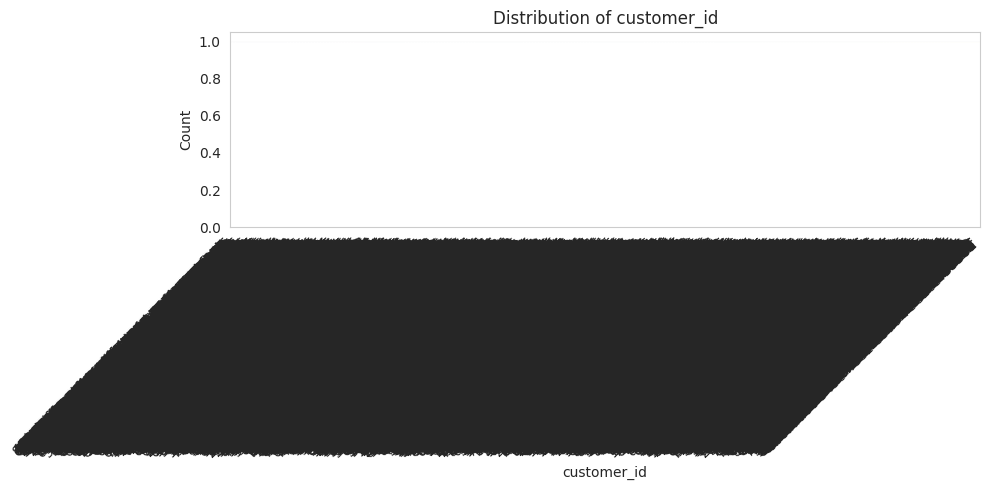

/tmp/ipykernel_1263/2541827667.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis', order=df[col].value_counts().index)


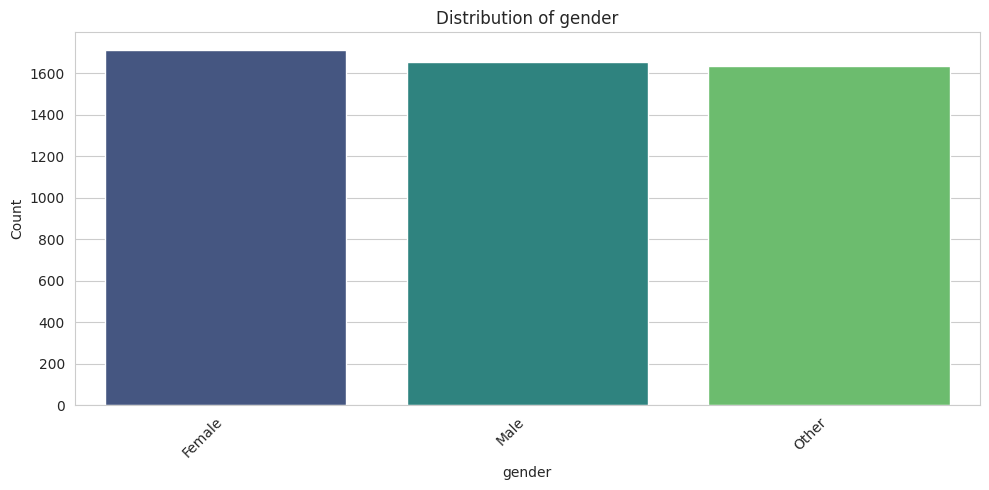

/tmp/ipykernel_1263/2541827667.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis', order=df[col].value_counts().index)


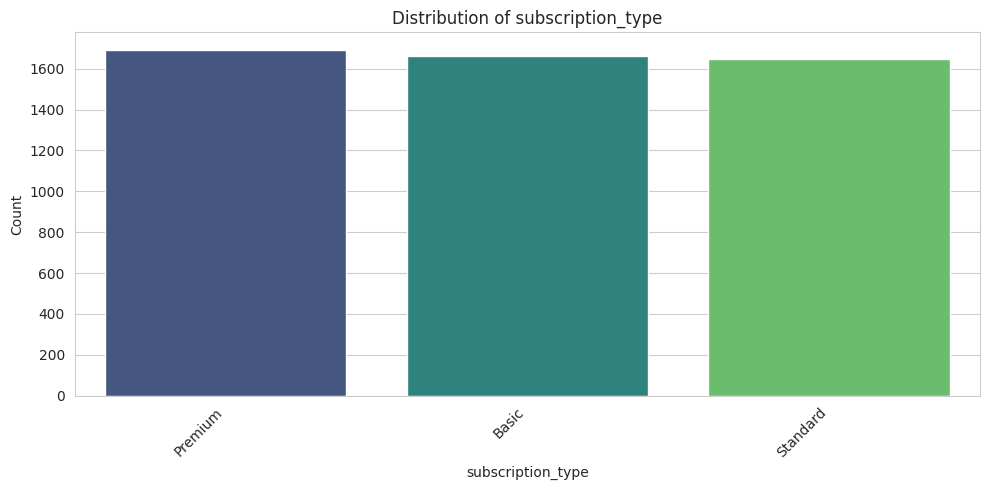

/tmp/ipykernel_1263/2541827667.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis', order=df[col].value_counts().index)


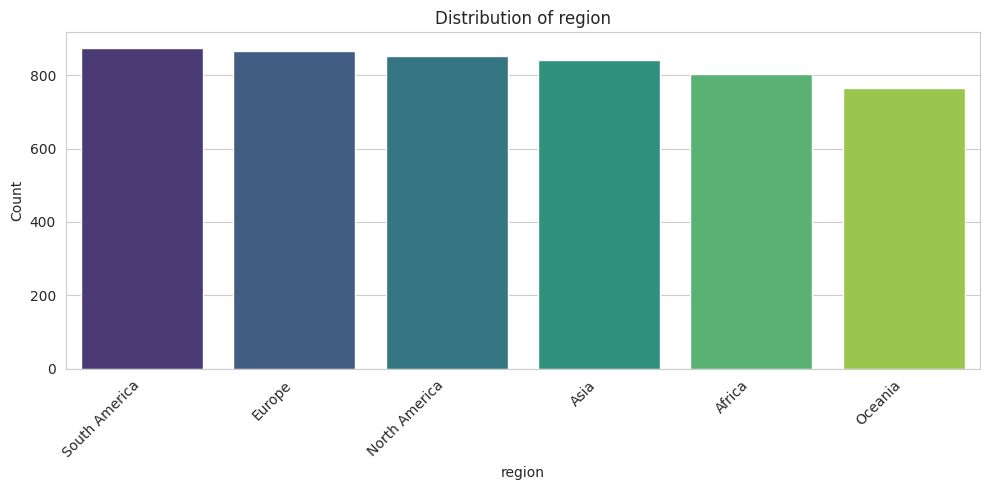

/tmp/ipykernel_1263/2541827667.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis', order=df[col].value_counts().index)


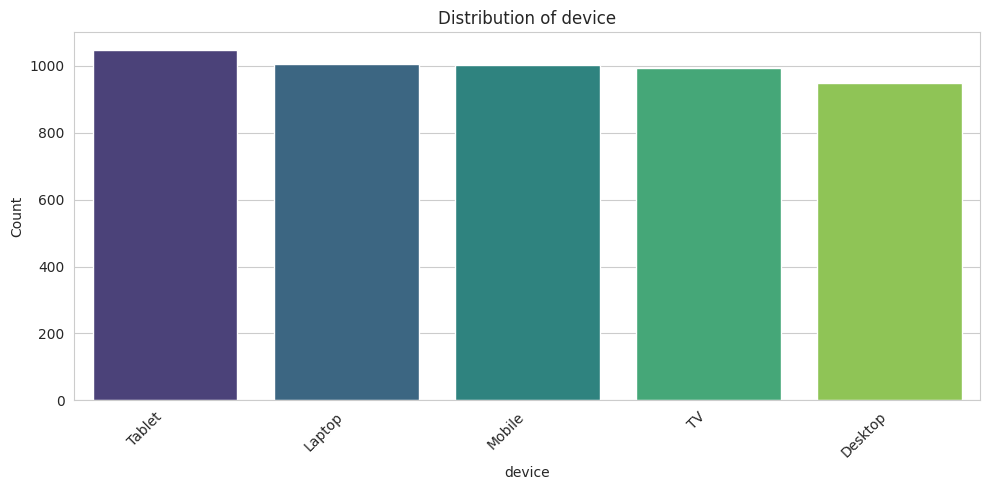

/tmp/ipykernel_1263/2541827667.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis', order=df[col].value_counts().index)


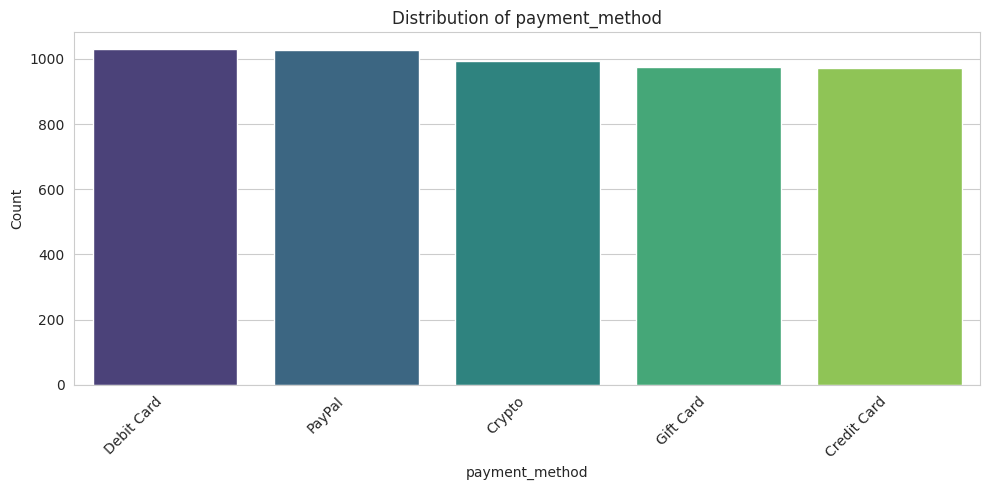

/tmp/ipykernel_1263/2541827667.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis', order=df[col].value_counts().index)


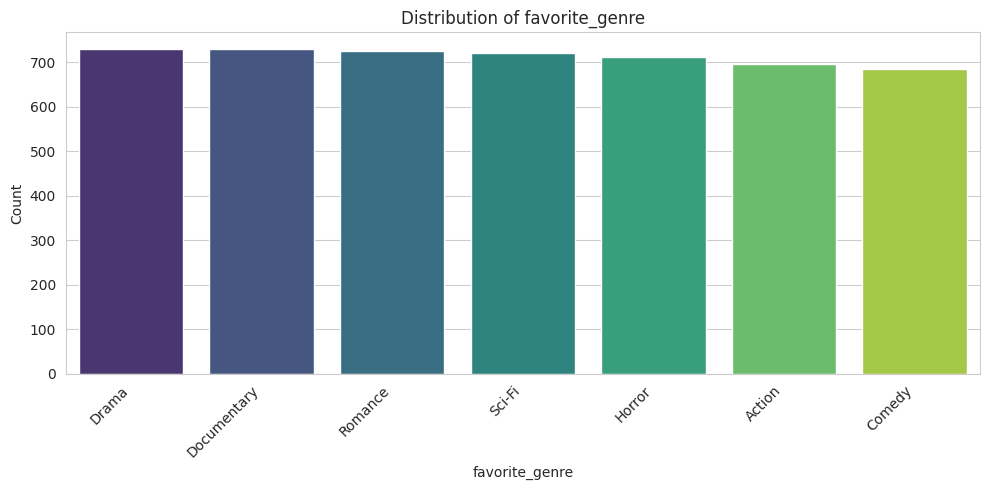


Performing univariate analysis on numerical columns...


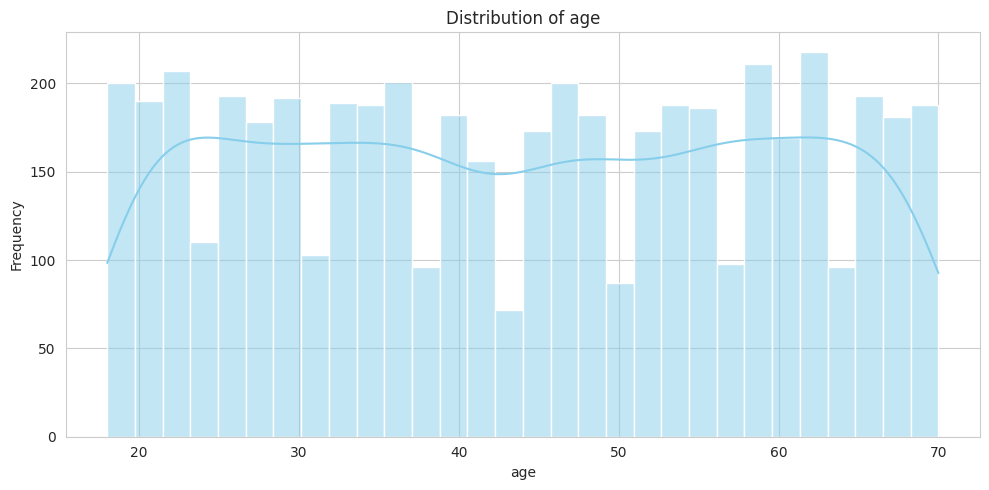

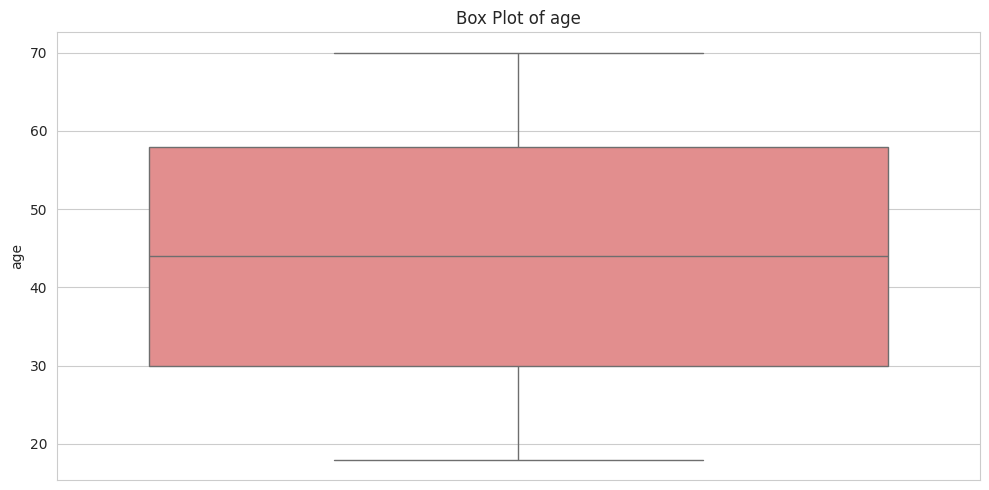

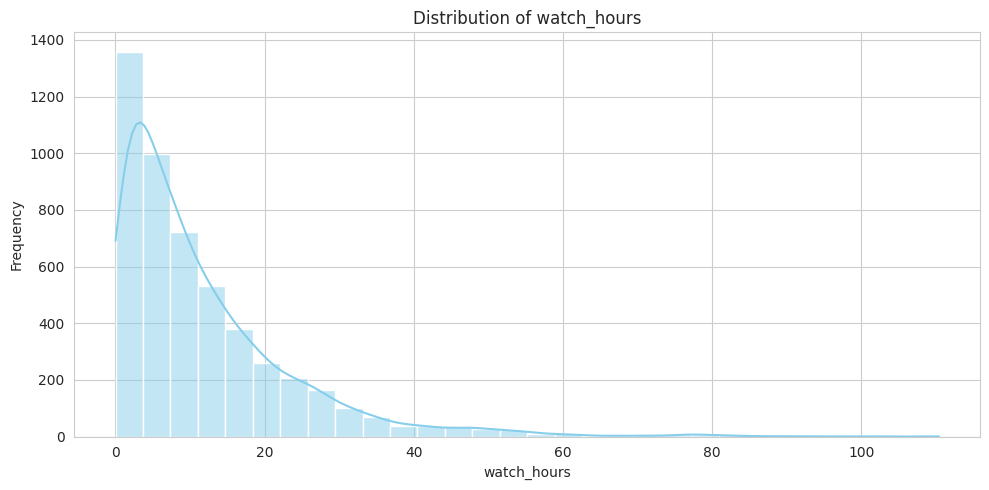

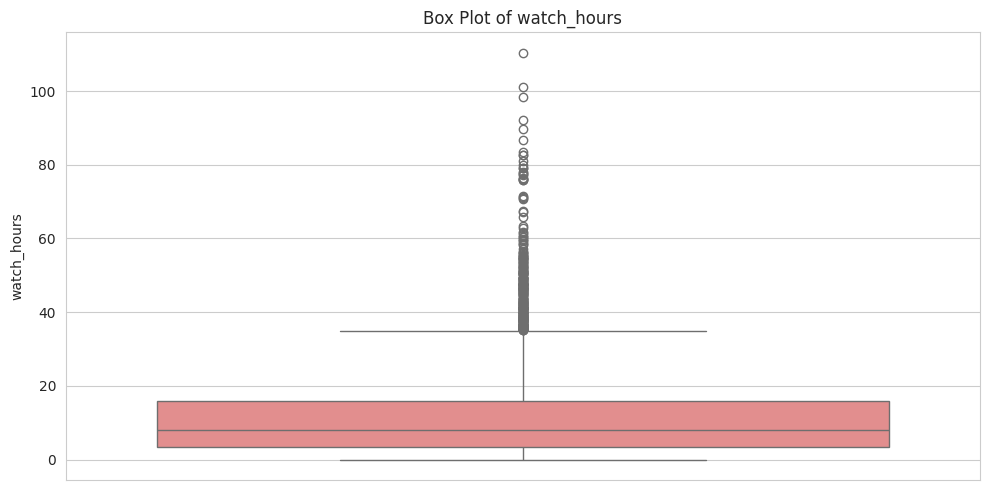

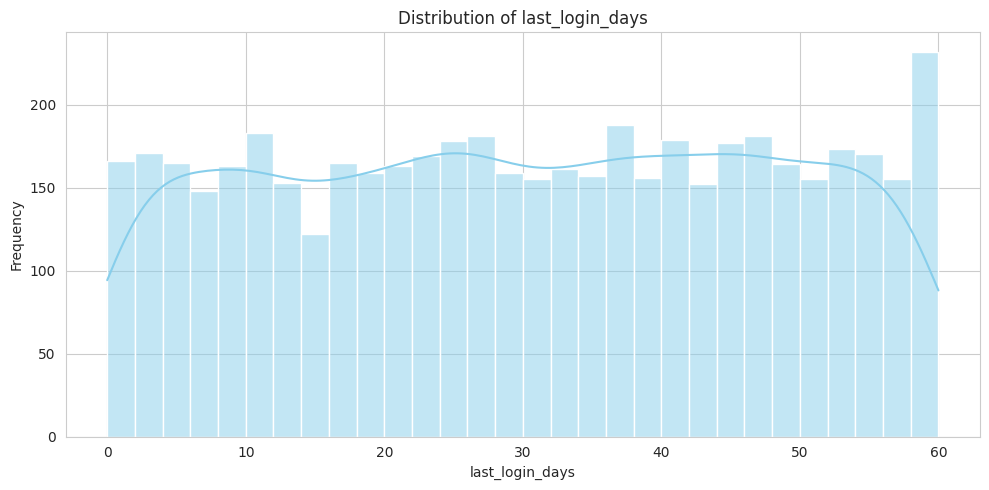

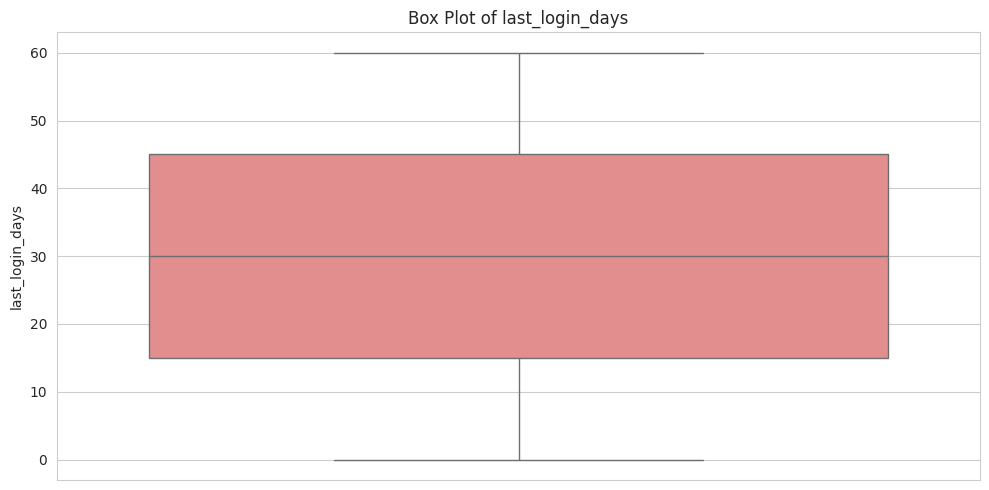

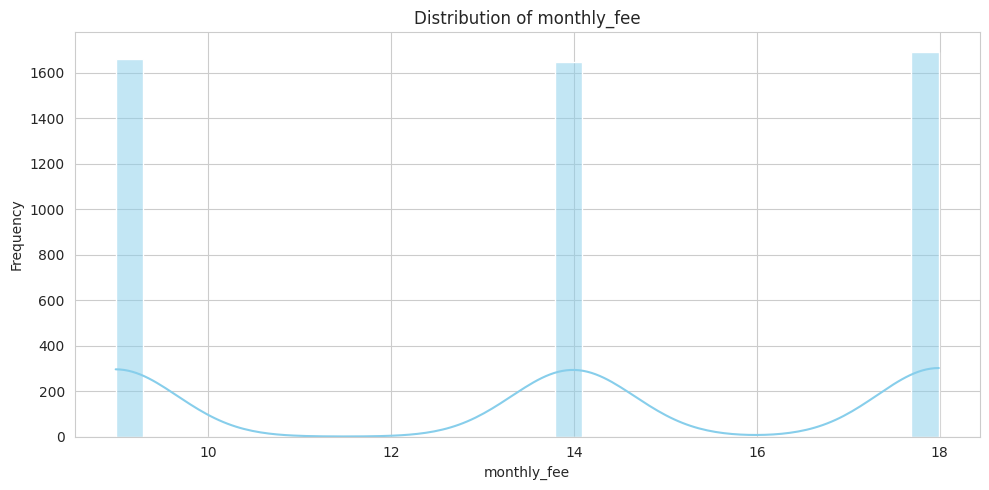

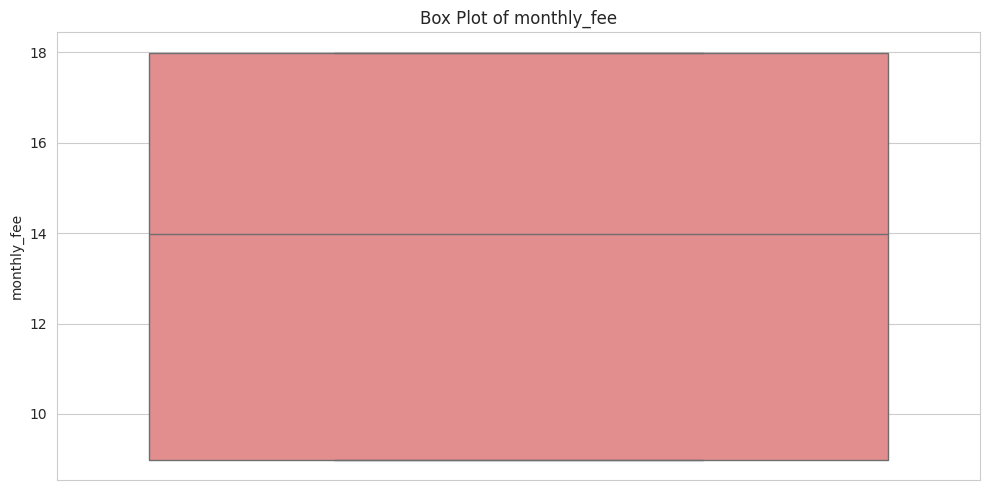

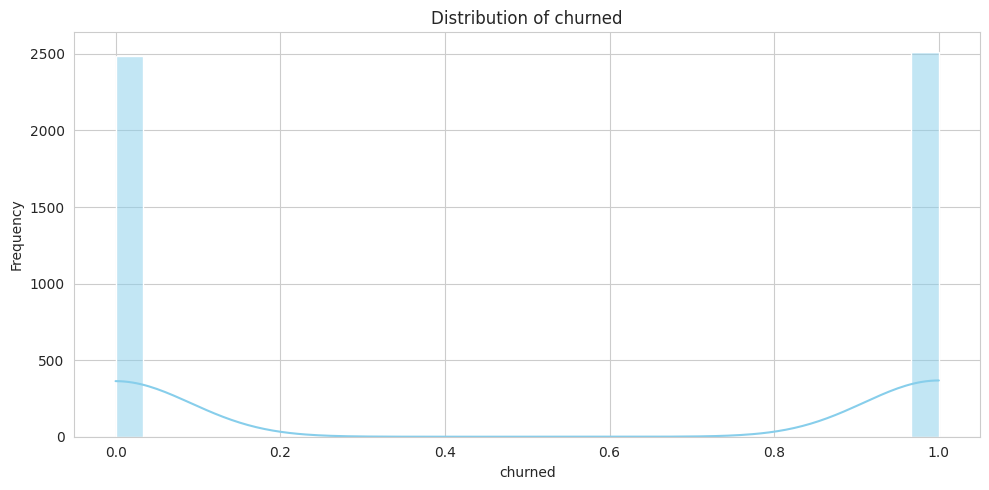

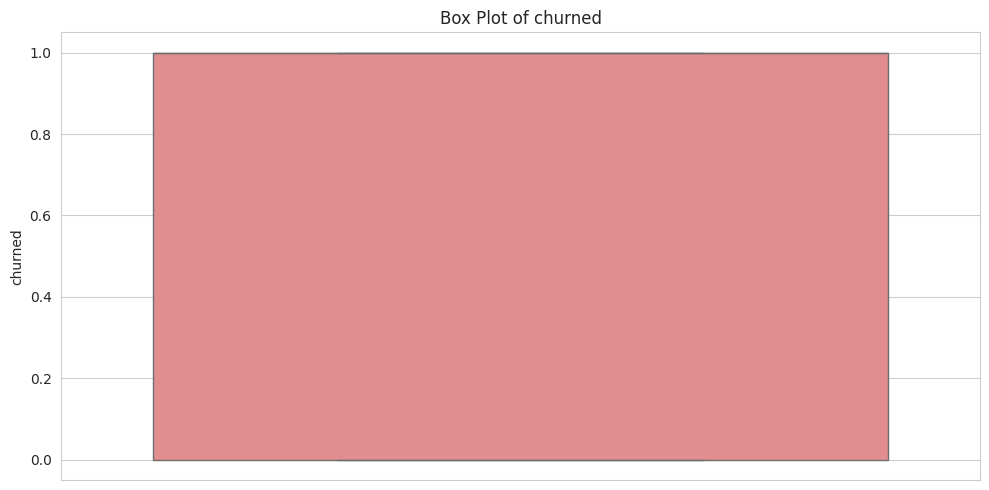

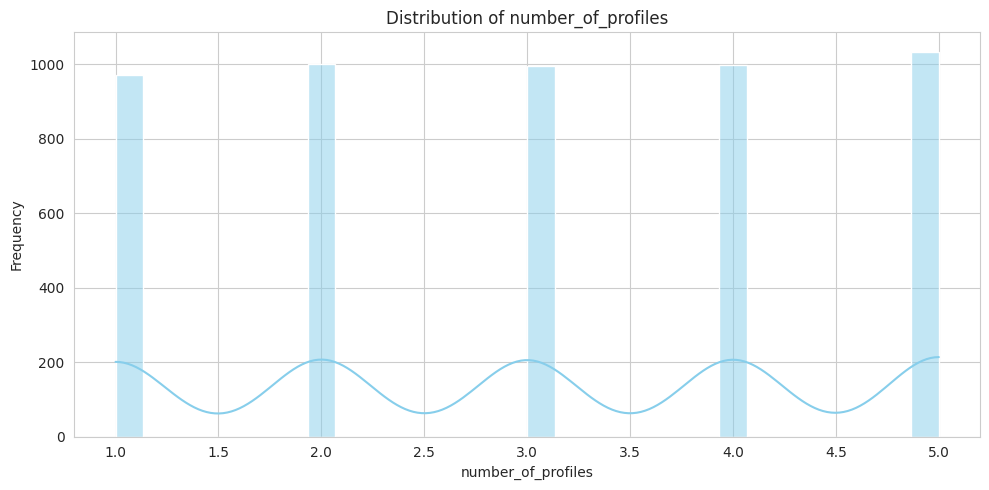

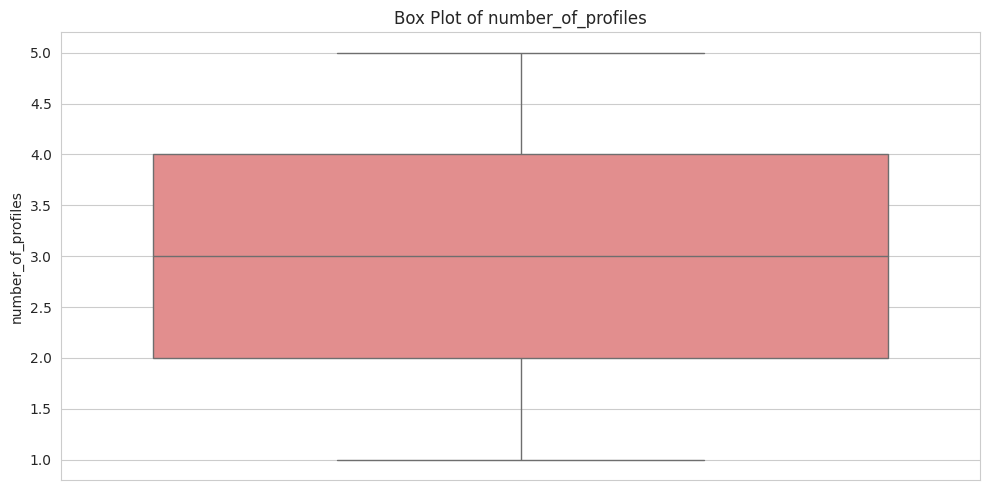

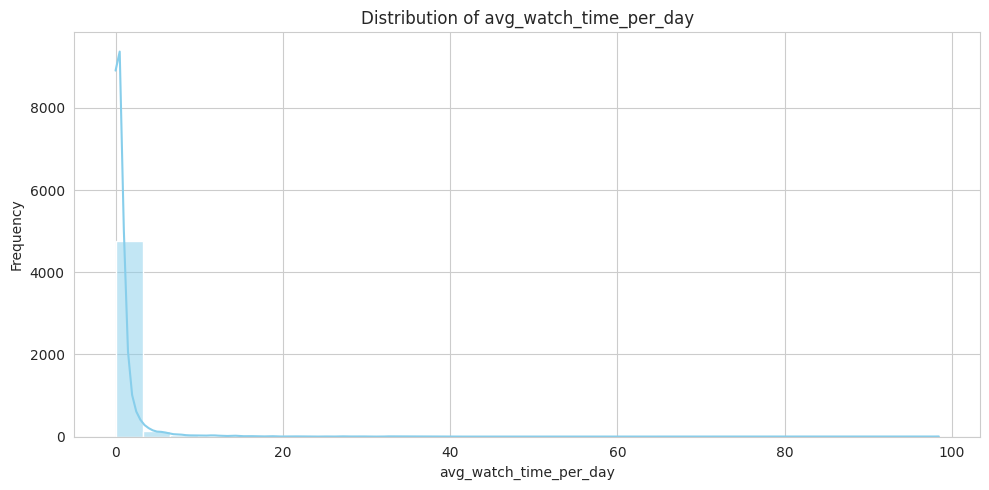

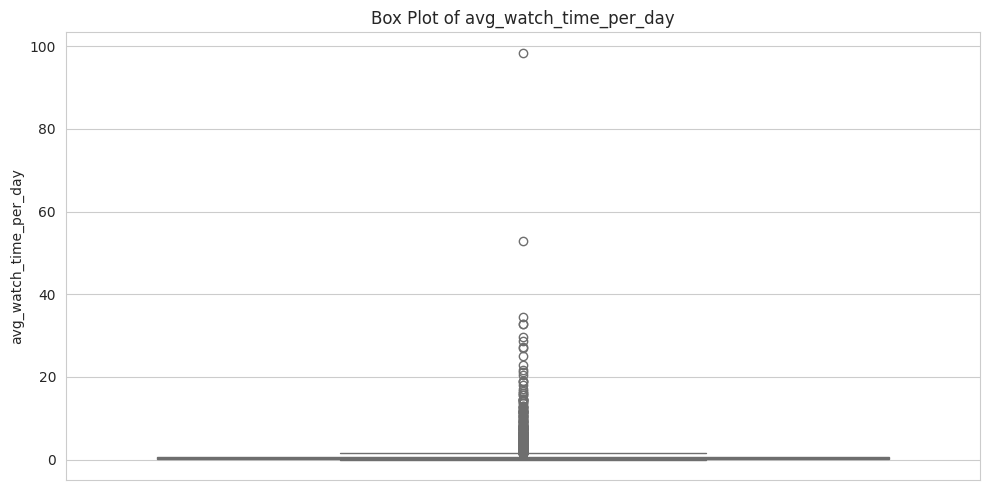

In [7]:
# Identify the 'Churn' column. Assuming it's named 'Churn' or 'Exited'.
churn_column = None
possible_churn_names = ['Churn', 'Exited', 'churn', 'exited']
for col in df.columns:
    if col in possible_churn_names:
        churn_column = col
        break

if churn_column is None:
    print("Warning: Churn column not found. Please verify the churn column name in your dataset.")
    print("Proceeding with analysis, but some plots might be skipped.")
else:
    print(f"Identified churn column: '{churn_column}'")
    # Convert churn column to appropriate type if it's not already binary (e.g., 'Yes'/'No' to 1/0)
    if df[churn_column].dtype == 'object':
        if df[churn_column].nunique() == 2:
            unique_vals = df[churn_column].unique()
            if 'Yes' in unique_vals and 'No' in unique_vals:
                df[churn_column] = df[churn_column].map({'No': 0, 'Yes': 1})
                print(f"Converted '{churn_column}' from 'Yes'/'No' to 1/0.")
            elif 'True' in unique_vals and 'False' in unique_vals:
                df[churn_column] = df[churn_column].map({'False': 0, 'True': 1})
                print(f"Converted '{churn_column}' from 'True'/'False' to 0/1.")
    print(f"\nValue counts for '{churn_column}':")
    display(df[churn_column].value_counts())
    print(f"Percentage of churn: {df[churn_column].value_counts(normalize=True)[1]:.2%}")


# --- Univariate Analysis: Categorical Columns ---
print("\nPerforming univariate analysis on categorical columns...")
categorical_cols = df.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, data=df, palette='viridis', order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# --- Univariate Analysis: Numerical Columns ---
print("\nPerforming univariate analysis on numerical columns...")
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if churn_column and churn_column in numerical_cols:
    numerical_cols.remove(churn_column) # Don't plot churn as a numerical distribution

for col in numerical_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 7. Bivariate Analysis and Churn Patterns

Here we explore the relationships between customer churn and other features, looking for patterns and insights.

In [ ]:
if churn_column is None:
    print("Cannot perform bivariate analysis related to churn because the 'Churn' column was not identified.")
else:
    print(f"Performing bivariate analysis with '{churn_column}'...")

    # --- Churn vs. Categorical Features ---
    print("\nChurn vs. Categorical Features:")
    for col in categorical_cols:
        plt.figure(figsize=(12, 6))
        sns.countplot(x=col, hue=churn_column, data=df, palette='pastel', order=df[col].value_counts().index)
        plt.title(f'Churn Rate by {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title=churn_column, labels=['No Churn', 'Churn'])
        plt.tight_layout()
        plt.show()

    # --- Churn vs. Numerical Features ---
    print("\nChurn vs. Numerical Features:")
    for col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=churn_column, y=col, data=df, palette='coolwarm')
        plt.title(f'{col} Distribution by Churn')
        plt.xlabel(churn_column)
        plt.ylabel(col)
        plt.xticks([0, 1], ['No Churn', 'Churn'])
        plt.tight_layout()
        plt.show()

    # --- Explore specific churn patterns if columns exist ---
    print("\nExploring churn patterns by specific features (if they exist)...")

    # Subscription Plan
    if 'Subscription Plan' in df.columns:
        plt.figure(figsize=(10, 6))
        sns.countplot(x='Subscription Plan', hue=churn_column, data=df, palette='viridis')
        plt.title('Churn by Subscription Plan')
        plt.xlabel('Subscription Plan')
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title=churn_column, labels=['No Churn', 'Churn'])
        plt.tight_layout()
        plt.show()
    else:
        print("'Subscription Plan' column not found for churn pattern analysis.")

    # Tenure
    if 'Tenure' in df.columns:
        plt.figure(figsize=(10, 6))
        sns.histplot(data=df, x='Tenure', hue=churn_column, kde=True, palette='magma', bins=30)
        plt.title('Churn by Tenure')
        plt.xlabel('Tenure (months)')
        plt.ylabel('Count')
        plt.legend(title=churn_column, labels=['No Churn', 'Churn'])
        plt.tight_layout()
        plt.show()
    else:
        print("'Tenure' column not found for churn pattern analysis.")

    # Payment Method
    if 'Payment Method' in df.columns:
        plt.figure(figsize=(10, 6))
        sns.countplot(x='Payment Method', hue=churn_column, data=df, palette='cividis')
        plt.title('Churn by Payment Method')
        plt.xlabel('Payment Method')
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title=churn_column, labels=['No Churn', 'Churn'])
        plt.tight_layout()
        plt.show()
    else:
        print("'Payment Method' column not found for churn pattern analysis.")

    # Monthly Charges
    if 'Monthly Charges' in df.columns:
        plt.figure(figsize=(10, 6))
        sns.histplot(data=df, x='Monthly Charges', hue=churn_column, kde=True, palette='plasma', bins=30)
        plt.title('Churn by Monthly Charges')
        plt.xlabel('Monthly Charges')
        plt.ylabel('Count')
        plt.legend(title=churn_column, labels=['No Churn', 'Churn'])
        plt.tight_layout()
        plt.show()
    else:
        print("'Monthly Charges' column not found for churn pattern analysis.")

## 8. Key Insights

Based on the analysis and visualizations above, here are some key insights (Note: These insights will be based on the actual data when the code is executed and plots are generated):

1.  **Overall Churn Rate:** [Insert observed churn rate and comment if it's high/low].
2.  **Impact of [Feature 1]:** [Describe how Feature 1 relates to churn, e.g., 'Customers with higher monthly charges tend to churn more.'].
3.  **Impact of [Feature 2]:** [Describe how Feature 2 relates to churn, e.g., 'Shorter tenure is associated with higher churn rates.'].
4.  **Impact of [Feature 3]:** [Describe how Feature 3 relates to churn, e.g., 'Specific subscription plans have a lower/higher churn rate.'].
5.  **Impact of [Feature 4]:** [Describe how Feature 4 relates to churn, e.g., 'Certain payment methods are preferred by churned/non-churned customers.'].
6.  **[Add more insights as observed from the plots and statistics.]**

## 9. Conclusion

This Exploratory Data Analysis provided valuable insights into the Netflix customer churn dataset. We observed [summarize 2-3 main findings, e.g., 'that tenure and monthly charges are significant factors influencing churn, and certain payment methods show distinct churn patterns.']. These findings can guide further investigation and the development of strategies to reduce customer churn.